### Objectives
1. Generate stims, load into tensors
2. Set up network architecture, loss functions/training structure, model eval 
3. Train/test
4. Visualize results: loss curves, response distribution, stim vs resp
5. Formal test for responses being more tightly locked to context thant to true stim
6. Save beh predictions, and hidden layer/embeddings/representations

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, scipy.stats as stats, torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

from sklearn.decomposition import PCA
from matplotlib.colors import Normalize

plot setting

In [2]:
# sns.set(context='paper')

# keep text editable in svg
plt.rcParams['svg.fonttype'] = 'none'

import matplotlib as mpl
# push ticks inward
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
# remove top and right splines
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

variables and functions

In [3]:
def set_seed(seed: int):
    # Reproducibility for python/numpy/torch RNGs
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

seed = 20260309

conds = ['curv', 'base', 'flat']
bounds = [0.25, 0.50, 0.75]

### 1. Generate stims, split into train/test, convert to tensors

generating unique trials

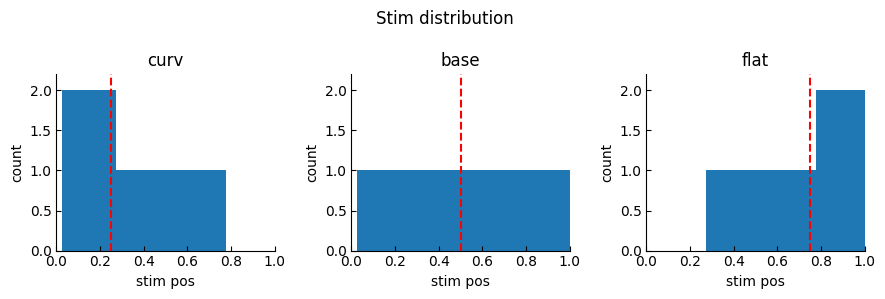

['curv', 'base', 'flat'] [0.25, 0.5, 0.75]
num unique trials: 60


,condition,stim,boundary,cond_unique_stim_idx,class
0,base,0.025,0.50,0,0
5,base,0.275,0.50,5,0
10,base,0.525,0.50,10,1
15,base,0.775,0.50,15,1
20,curv,0.025,0.25,0,0
25,curv,0.125,0.25,2,0
30,curv,0.275,0.25,5,1
35,curv,0.525,0.25,10,1
40,flat,0.275,0.75,0,0
45,flat,0.525,0.75,5,0


In [4]:
psychopy_df = pd.read_csv(f'../../data/psychopy/trials_patients_v2.csv', index_col=False)

# choose only 1st half of session, and every other trial
unique_trials_df = psychopy_df[:120][::2].copy().reset_index(drop=True)
assert len(unique_trials_df) == 60, "Expected 60 unique trials after filtering."

# renames
unique_trials_df = unique_trials_df.rename(columns={'stim_pos': 'stim', 'true_div': 'boundary'})
unique_trials_df['condition'] = unique_trials_df['condition'].map({'curv_comp': 'curv', 'baseline': 'base', 'flat_comp': 'flat'})

# drops
unique_trials_df.drop(columns=['blockN', 'trial_key', 'noise_pos', 'shape', 'run', 'div_pos', 'stim_file_pos', 'target_pos', 'marker_init', 'shape_order', 'valence', 'target_file', 'img1_file', 'img2_file', 'valence_direction', 'direction', 'marker_direction', 'noise_direction', 'shape_category'], inplace=True)
unique_trials_df.reset_index(drop=True, inplace=True)

# adds
# cond_unique_stim_idx: groups rows by unique stimulus & condition
unique_trials_df['cond_unique_stim_idx'] = unique_trials_df.groupby('boundary')['stim'].transform(lambda x: pd.factorize(x)[0])
unique_trials_df['class'] = (unique_trials_df['stim'] > unique_trials_df['boundary']).astype(int)  # 0 or 1 based on stim vs boundary

# norm stim and boundary to 0-1 range
unique_trials_df['stim'] = (unique_trials_df['stim'] + 0.4) / 0.8
unique_trials_df['boundary'] = (unique_trials_df['boundary'] + 0.4) / 0.8

fig, axs = plt.subplots(1, 3, figsize=(9, 3))
axs, ax = axs.flatten(), 0
step = 0.04/.8  # ~ .05, fixed step between stim positions
plt.suptitle('Stim distribution')

for cond in ['curv', 'base', 'flat']:

    axs[ax].set(title=cond, xlabel='stim pos', ylabel='count', xlim=(0,1), ylim=(0, 2.2))
    cond_df = unique_trials_df[unique_trials_df['condition'] == cond]
    axs[ax].hist(cond_df['stim'], bins=np.arange(0 - step/2, 1 + step, step)) 
    axs[ax].axvline(cond_df['boundary'].iloc[0], color='red', linestyle='--')   
    ax += 1

plt.tight_layout()
plt.show()

print(conds, bounds)
print(f'num unique trials: {len(unique_trials_df)}')

unique_trials_df[::5]

generated noised repeats of unique trials

In [5]:
# repeats
n_trial_reps, trial_rep_noise = 10, 0.1       # noise added to X_train tensors (regularization)
all_trials_df = pd.concat([unique_trials_df.assign(rep=i) for i in range(n_trial_reps)], ignore_index=True)

# noise
rng = np.random.default_rng(seed)
all_trials_df['stim_noised'] = all_trials_df['stim'] + rng.normal(0, trial_rep_noise, size=len(all_trials_df))
# all_trials_df['boundary_noised'] = all_trials_df['boundary'] + rng.normal(0, trial_rep_noise, size=len(all_trials_df))

# show top row from each rep
all_trials_df.groupby('rep').first().reset_index()


,rep,condition,stim,boundary,cond_unique_stim_idx,class,stim_noised
0,0,base,0.025,0.5,0,0,-0.007824
1,1,base,0.025,0.5,0,0,-0.015878
2,2,base,0.025,0.5,0,0,0.033121
3,3,base,0.025,0.5,0,0,-0.077145
4,4,base,0.025,0.5,0,0,-0.067450
5,5,base,0.025,0.5,0,0,0.047042
6,6,base,0.025,0.5,0,0,0.116386
7,7,base,0.025,0.5,0,0,-0.027926
8,8,base,0.025,0.5,0,0,-0.053388
9,9,base,0.025,0.5,0,0,-0.126476


split into train/test

In [6]:
test_frac = 0.30
all_trials_df['train/test'] = ''
train_idx, test_idx = [], []

# grab each combo of unique_stim, cond, class
for _, unique_combo in all_trials_df.groupby(['cond_unique_stim_idx', 'condition', 'class']):
    combo_idxs = unique_combo.index.to_numpy().copy()
    np.random.default_rng(seed).shuffle(combo_idxs)
    n_test = int(np.round(len(combo_idxs) * test_frac))
    test_idx.extend(combo_idxs[:n_test])
    train_idx.extend(combo_idxs[n_test:])

all_trials_df.loc[train_idx, 'train/test'] = 'train'
all_trials_df.loc[test_idx, 'train/test'] = 'test'
train_df = all_trials_df.loc[train_idx].reset_index(drop=True)
test_df = all_trials_df.loc[test_idx].reset_index(drop=True)

print('number of trials:')
print(f'unique/eval: {len(unique_trials_df)} | total (noised, excluding unique/eval): {len(all_trials_df)}')
print(f'train: {len(train_df)} | test: {len(test_df)}')

all_trials_df.groupby('rep').first().reset_index()


number of trials:
unique/eval: 60 | total (noised, excluding unique/eval): 600
train: 420 | test: 180


,rep,condition,stim,boundary,cond_unique_stim_idx,class,stim_noised,train/test
0,0,base,0.025,0.5,0,0,-0.007824,train
1,1,base,0.025,0.5,0,0,-0.015878,train
2,2,base,0.025,0.5,0,0,0.033121,train
3,3,base,0.025,0.5,0,0,-0.077145,test
4,4,base,0.025,0.5,0,0,-0.067450,train
5,5,base,0.025,0.5,0,0,0.047042,train
6,6,base,0.025,0.5,0,0,0.116386,train
7,7,base,0.025,0.5,0,0,-0.027926,train
8,8,base,0.025,0.5,0,0,-0.053388,test
9,9,base,0.025,0.5,0,0,-0.126476,test


convert to tensors

In [7]:
# df -> tensors
def df_to_tensors(df, split):
    # noise for train, no noise for test
    if split == 'train': X = torch.tensor(df[['stim_noised', 'boundary']].values.copy(), dtype=torch.float32)
    else:                X = torch.tensor(df[['stim', 'boundary']].values.copy(), dtype=torch.float32)
    y_class = torch.tensor(df[['class']].values.copy(), dtype=torch.float32)
    y_stim = torch.tensor(df[['stim']].values.copy(), dtype=torch.float32)
    return X, y_class, y_stim

X_train, y_class_train, y_stim_train = df_to_tensors(train_df, 'train')
X_test, y_class_test, y_stim_test = df_to_tensors(test_df, 'test')
X_eval, y_class_eval, y_stim_eval = df_to_tensors(unique_trials_df, 'test')

print(f'train: X({X_train.shape}), y_class({y_class_train.shape}), y_stim({y_stim_train.shape})')
print(f'test: X({X_test.shape}), y_class({y_class_test.shape}), y_stim({y_stim_test.shape})')
print(f'eval: X({X_eval.shape}), y_class({y_class_eval.shape}), y_stim({y_stim_eval.shape})')

train: X(torch.Size([420, 2])), y_class(torch.Size([420, 1])), y_stim(torch.Size([420, 1]))
test: X(torch.Size([180, 2])), y_class(torch.Size([180, 1])), y_stim(torch.Size([180, 1]))
eval: X(torch.Size([60, 2])), y_class(torch.Size([60, 1])), y_stim(torch.Size([60, 1]))


### 2. network architecture, loss functions for train/test, model evaluation

architecture & parameters

In [8]:
# --- Architecture ---
class BoundaryNet(nn.Module):
    """
    2-input → 10-unit hidden → 2-output boundary network.
    Inputs   : [stim ∈ (0,1),  boundary ∈ {0.25, 0.50, 0.75}]
    Hidden   : 10 units, ReLU
    fc2_reg  : linear → graded position response
    fc2_class: linear → logit for BCE classification (dedicated head, targets 0/1)
    """
    def __init__(self, in_dim: int = 2, hidden_dim: int = 5):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2_reg = nn.Linear(hidden_dim, 1)
        self.fc2_class = nn.Linear(hidden_dim, 1)

    def forward_with_hidden(self, x: torch.Tensor):
        """Return (position_output, class_logit, hidden_activations) for analysis."""
        hidden = F.relu(self.fc1(x))
        y_pred = self.fc2_reg(hidden)
        class_logit_pred = self.fc2_class(hidden)
        return y_pred, class_logit_pred, hidden

print('BoundaryNet, run_epoch, and evaluate_model_on_df defined.')
BoundaryNet()

def correlation_loss(pred, target):
    pred = pred.squeeze()
    target = target.squeeze()
    vx = pred - pred.mean()
    vy = target - target.mean()
    corr = (vx * vy).sum() / (torch.sqrt((vx ** 2).sum()) * torch.sqrt((vy ** 2).sum()) + 1e-8)
    return 1 - corr  # or -corr if you want to maximize

lr = 1e-2

# loss weights
bce_wt = 1    # classification BCE
mse_wt  = 1  # regression MSE
exp_bound_wt = .5   # boundary-attraction MSE on expanded-class trials only
corr_wt = 0     # correlation y & y_pred

# convergence criteria
class_acc_target = 0.8 # rolling-window train classification accuracy that triggers early stopping
mse_target = 0.005  # rolling-window train_loss_mse that triggers early stopping
max_epochs = 250   # hard cap — training always stops here even without convergence
min_epochs = 15    # burn-in period: convergence is not checked before this epoch
conv_window = 20   # number of recent epochs averaged to assess convergence


BoundaryNet, run_epoch, and evaluate_model_on_df defined.


train/test setup

In [9]:
# full batch gradient descent (no dataloader) since dataset is small and we want to compute losses on all trials each epoch
def run_epoch(model, X, y_class, y_stim, optimizer=None):
    
    # if optimizer passed, we are in training mode, and gradients will be updated
    training = optimizer is not None
    model.train(training)

    with torch.set_grad_enabled(training):

        # predictions
        y_preds, class_logits, _ = model.forward_with_hidden(X)

        # get boundary location and whether class is expanded
        bounds = X[:, 1:2]  # boundary column (noised during train, clean during eval)
        are_exps = (((y_class == 0) & (bounds == .75)) | ((y_class == 1) & (bounds == 0.25))).squeeze(1)

        # losses
        mse_losses = F.mse_loss(y_preds, y_stim)

        if are_exps.any(): exp_bound_losses = F.mse_loss(y_preds[are_exps], bounds[are_exps])
        else:            exp_bound_losses = torch.tensor(0.0)

        bce_losses = F.binary_cross_entropy_with_logits(class_logits, y_class)

        corr_losses = correlation_loss(y_preds, y_stim)

        total_losses = (mse_wt * mse_losses) + (exp_bound_wt * exp_bound_losses) + corr_wt * corr_losses + bce_wt * bce_losses

        if training: optimizer.zero_grad(); total_losses.backward(); optimizer.step()

        n = X.size(0)
        correct = ((y_preds >= bounds).float() == y_class).sum().item()

    return {
        'total_losses':     total_losses.item(),
        'mse_losses':       mse_losses.item(),
        'exp_bound_losses': exp_bound_losses.item(),
        'bce_losses':       bce_losses.item(),
        'corr_losses':      corr_losses.item(),
        'class_acc':            correct / n,
    }


inference setup

In [10]:
def evaluate_model_on_df(model, unique_trials_df):

    X_eval, y_class_eval, y_stim_eval = df_to_tensors(unique_trials_df, 'test')

    model.eval()
    with torch.no_grad():  y_pred, class_logit_pred, hidden = model.forward_with_hidden(X_eval)

    pred_df = unique_trials_df.copy()
    pred_df['y_pred']       = y_pred.squeeze(1).numpy()
    pred_df['class_pred'] = class_logit_pred.squeeze(1).numpy()

    perform_metrics = run_epoch(model, X_eval, y_class_eval, y_stim_eval)

    return pred_df, hidden.numpy(), perform_metrics


### 3. Run model
per network, train/test -> infer -> save

In [11]:
n_nets = 30
all_nets_detailed_res = [] # 1 row per net

for net_idx in range(n_nets):

    set_seed(seed + net_idx)
    model = BoundaryNet(in_dim=2, hidden_dim=10)
    optimizer = Adam(model.parameters(), lr=lr)
    net_train_test_res, converged = [], False

    # 1. train/test
    for epoch in range(max_epochs):

        train_stats = run_epoch(model, X_train, y_class_train, y_stim_train, optimizer=optimizer)
        test_stats = run_epoch(model, X_test, y_class_test, y_stim_test)

        # store epoch, train/test losses, train/test accuracy
        train_test_res = {'net_idx': net_idx, 'epoch': epoch,
                     **{f"train_{k}": v for k, v in train_stats.items()},
                     **{f"test_{k}": v for k, v in test_stats.items()}}
        net_train_test_res.append(train_test_res)

        # decide whether to stop training based on convergence criteria
        if epoch >= min_epochs and len(net_train_test_res) >= conv_window:
            # avg train classification accuracy over the last `conv_window` epochs.
            recent_train_acc   = np.mean([last_n_epoch['train_class_acc']  for last_n_epoch in net_train_test_res[-conv_window:]])
            if recent_train_acc >= class_acc_target: converged = True; break  # exit the epoch loop; model is considered trained

    net_train_test_res_df = pd.DataFrame(net_train_test_res) # len = num_epochs

    # 2. eval/infer on unseen, de-noised trials
    unique_trials_df_3x = pd.concat([unique_trials_df] * 3, ignore_index=True)  # to match expt
    net_eval_pred_df, net_eval_hidden, net_eval_perform_metrics =\
        evaluate_model_on_df(model, unique_trials_df_3x)

    # 3. append. num_rows = num_nets.
    all_nets_detailed_res.append({
        'seed': seed + net_idx, 'model': model, 'net_idx': net_idx,
        'train_test_res_df': net_train_test_res_df, 'converged': converged, 'num_epochs': len(net_train_test_res_df),
        'eval_pred_df': net_eval_pred_df, 'eval_hidden_arr': net_eval_hidden, 'eval_performance_dict': net_eval_perform_metrics})

all_nets_summaries_df = pd.DataFrame({ 
    'seed':                [net['seed'] for net in all_nets_detailed_res],

    'train_total_loss':    [net['train_test_res_df']['train_total_losses'].iloc[-1] for net in all_nets_detailed_res],
    'train_class_acc':     [net['train_test_res_df']['train_class_acc'].iloc[-1] for net in all_nets_detailed_res],
    'test_total_loss':     [net['train_test_res_df']['test_total_losses'].iloc[-1] for net in all_nets_detailed_res],
    'test_class_acc':      [net['train_test_res_df']['test_class_acc'].iloc[-1] for net in all_nets_detailed_res],
    'converged':           [net['converged'] for net in all_nets_detailed_res],
    'num_epochs':          [net['num_epochs'] for net in all_nets_detailed_res],
        
    'eval_total_loss':     [net['eval_performance_dict']['total_losses'] for net in all_nets_detailed_res],
    'eval_class_acc':      [net['eval_performance_dict']['class_acc']    for net in all_nets_detailed_res]})

assert len(all_nets_summaries_df) == n_nets, f"Expected {n_nets} network summaries, got {len(all_nets_summaries_df)}"
print(f'len(all_nets_summaries_df) == n_nets')

all_nets_summaries_df.head()


len(all_nets_summaries_df) == n_nets


,seed,train_total_loss,train_class_acc,test_total_loss,test_class_acc,converged,num_epochs,eval_total_loss,eval_class_acc
0,20260309,0.606268,0.878571,0.592366,0.933333,True,43,0.592366,0.933333
1,20260310,0.612438,0.871429,0.600656,0.900000,True,41,0.600656,0.900000
2,20260311,0.561754,0.890476,0.547911,1.000000,True,69,0.547911,1.000000
3,20260312,0.582252,0.888095,0.567929,0.950000,True,61,0.567929,0.950000
4,20260313,0.645653,0.864286,0.634675,0.950000,True,56,0.634675,0.950000


example network

In [12]:
(all_nets_detailed_res[0]['eval_pred_df'])

,condition,stim,boundary,cond_unique_stim_idx,class,y_pred,class_pred
0,base,0.025,0.50,0,0,0.207855,-0.699431
1,base,0.075,0.50,1,0,0.240331,-0.634813
2,base,0.125,0.50,2,0,0.271536,-0.553386
3,base,0.175,0.50,3,0,0.302674,-0.471079
4,base,0.225,0.50,4,0,0.333813,-0.388771
...,...,...,...,...,...,...,...
175,flat,0.875,0.75,12,1,0.855549,0.565947
176,flat,0.925,0.75,13,1,0.858664,0.595080
177,flat,0.925,0.75,13,1,0.858664,0.595080
178,flat,0.975,0.75,14,1,0.861779,0.624214


### 4. Check results

loss curves

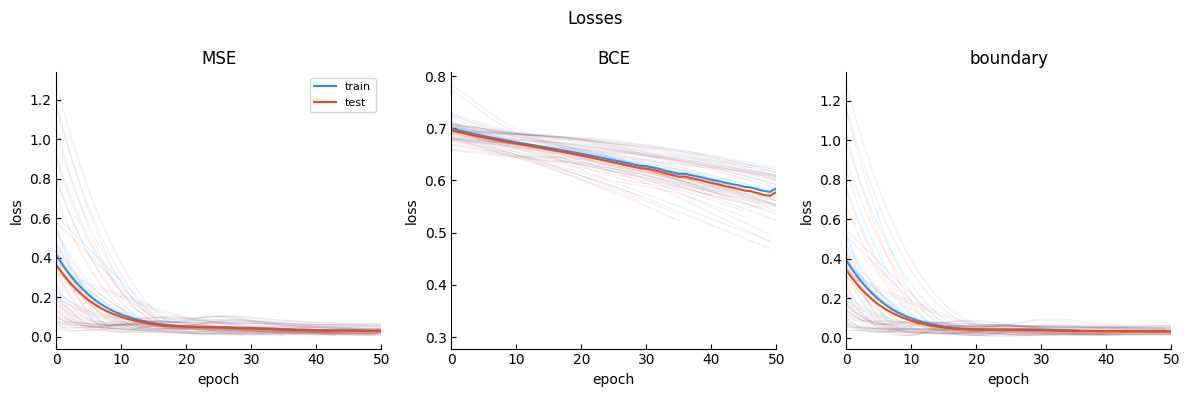

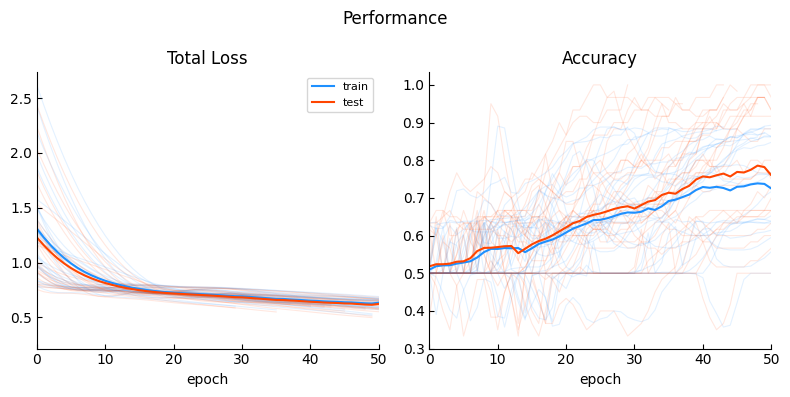

In [13]:
# ── Concatenate all per-epoch records across networks ─────────────────────────
all_epochs = pd.concat([net['train_test_res_df']
                        for net in all_nets_detailed_res], ignore_index=True)
epoch2plot = 50

# ── Losses ────────────────────────────────────────────────────────────────────
n_rows, n_cols = 1, 3
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axs = axs.flatten()
plt.suptitle('Losses')

for ax, (title, train_col, test_col) in zip(axs, [
    ('MSE',      'train_mse_losses',      'test_mse_losses'),
    ('BCE',      'train_bce_losses',      'test_bce_losses'),
    ('boundary', 'train_exp_bound_losses','test_exp_bound_losses'),
]):
    for _, grp in all_epochs.groupby('net_idx'):
        ax.plot(grp['epoch'], grp[train_col], color='dodgerblue', alpha=0.12, linewidth=0.8)
        ax.plot(grp['epoch'], grp[test_col],  color='orangered',  alpha=0.12, linewidth=0.8)
    mn = all_epochs.groupby('epoch')[[train_col, test_col]].mean()
    ax.plot(mn.index, mn[train_col], color='dodgerblue', linewidth=1.5, label='train')
    ax.plot(mn.index, mn[test_col],  color='orangered',  linewidth=1.5, label='test')
    ax.set(title=title, xlabel='epoch', ylabel='loss', xlim=(0, epoch2plot))

axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

# ── Performance ───────────────────────────────────────────────────────────────
n_rows, n_cols = 1, 2
fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axs = axs.flatten()
plt.suptitle('Performance')

for ax, (title, train_col, test_col) in zip(axs, [
    ('Total Loss', 'train_total_losses', 'test_total_losses'),
    ('Accuracy',   'train_class_acc',    'test_class_acc'),
]):
    for _, grp in all_epochs.groupby('net_idx'):
        ax.plot(grp['epoch'], grp[train_col], color='dodgerblue', alpha=0.12, linewidth=0.8)
        ax.plot(grp['epoch'], grp[test_col],  color='orangered',  alpha=0.12, linewidth=0.8)
    mn = all_epochs.groupby('epoch')[[train_col, test_col]].mean()
    ax.plot(mn.index, mn[train_col], color='dodgerblue', linewidth=1.5, label='train')
    ax.plot(mn.index, mn[test_col],  color='orangered',  linewidth=1.5, label='test')
    ax.set(title=title, xlabel='epoch', ylabel='', xlim=(0, epoch2plot))

axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


response distributions

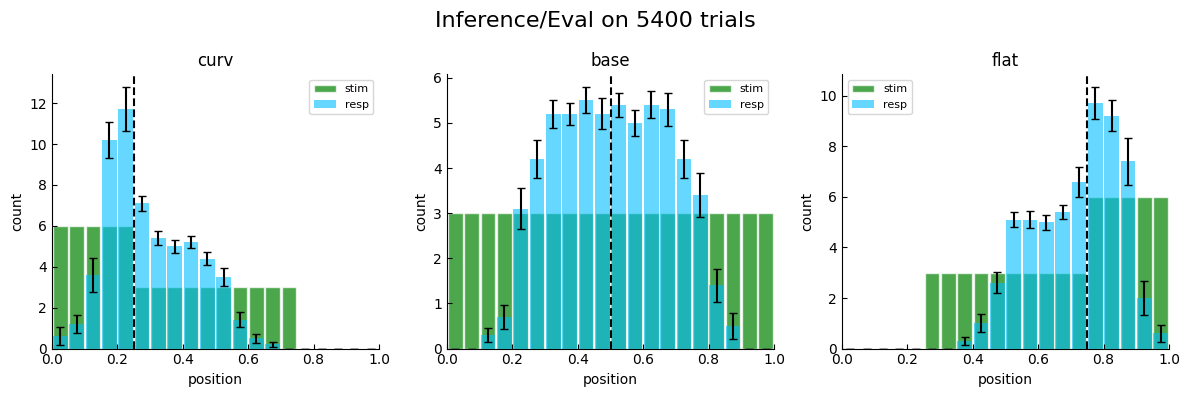

In [14]:
# collect all network predictions on eval set
eval_df = pd.concat([net['eval_pred_df'].assign(net_idx=net['net_idx'])
                    for net in all_nets_detailed_res], ignore_index=True)

b_colors = {'curv': 'orangered', 'base': 'gray', 'flat': 'dodgerblue'}
n_bins = 20

# --- Plot 1: Response histogram (1×3, per condition) ---
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs, ax = axs.flatten(), 0
plt.suptitle(f'Inference/Eval on {len(eval_df)} trials', fontsize=16)

for cond in conds:
    cond_df = eval_df[eval_df['condition'] == cond]

    resp_cts = []
    for _, net_df in cond_df.groupby('net_idx'):
        counts, _ = np.histogram(net_df['y_pred'], bins=n_bins, range=(0, 1))
        resp_cts.append(counts)
    resp_cts = np.array(resp_cts)

    mean_cts = resp_cts.mean(axis=0)
    sem_cts  = resp_cts.std(axis=0) / np.sqrt(resp_cts.shape[0])
    bin_centers = np.linspace(0, 1, n_bins, endpoint=False) + 0.5 / n_bins

    # true stimulus distribution for this condition (noisy)
    stim_vals = test_df[test_df['condition'] == cond]['stim'].values
    stim_cts, _ = np.histogram(stim_vals, bins=n_bins, range=(0, 1))

    # overlay: stim dist in muted color behind, response dist in front
    axs[ax].bar(bin_centers, stim_cts, width=1/n_bins * 0.9, color='green', edgecolor='white', alpha=0.7, label='stim')
    axs[ax].bar(bin_centers, mean_cts, width=1/n_bins * 0.9, color='deepskyblue', alpha=0.6, yerr=sem_cts, capsize=3, label='resp')
    axs[ax].axvline(cond_df['boundary'].iloc[0], color='black', linestyle='--')
    axs[ax].set(title=cond, xlabel='position', ylabel='count', xlim=(0, 1))
    axs[ax].legend(fontsize=8)
    ax += 1

plt.tight_layout()
plt.show()


In [15]:
for cond_i in range(len(conds)):
    cond, bound = conds[cond_i], bounds[cond_i]
    sub = eval_df[eval_df['condition'] == cond]
    y_true = sub['class'].values
    y_pred = (sub['y_pred'].values >= bound).astype(float)

    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()

    print(f'{cond} (b={bound:.2f}) | TP={tp:4d}  TN={tn:4d}  FP={fp:4d}  FN={fn:4d}  '
          f'acc={( tp + tn) / (tp + tn + fp + fn):.3f}')


curv (b=0.25) | TP= 879  TN= 798  FP= 102  FN=  21  acc=0.932
base (b=0.50) | TP= 891  TN= 873  FP=  27  FN=   9  acc=0.980
flat (b=0.75) | TP= 834  TN= 867  FP=  33  FN=  66  acc=0.945


b. stimulus vs response, by context

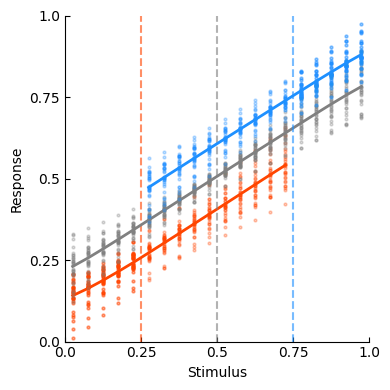

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.set(xlabel='Stimulus', ylabel='Response', xlim=(0, 1), ylim=(0, 1),
       xticks=np.linspace(0, 1, 5), yticks=np.linspace(0, 1, 5),
       xticklabels=np.linspace(0, 1, 5), yticklabels=np.linspace(0, 1, 5))

for cond_i in range(len(conds)):
    cond, bound = conds[cond_i], bounds[cond_i]
    cond_df = eval_df[eval_df['condition'] == cond]
    
    ax.plot(cond_df['stim'], cond_df['y_pred'], 'o', markersize=2, alpha=0.1, color=b_colors[cond])
    ax.axvline(bound, color=b_colors[cond], linestyle='--', alpha=0.6)
    
    mean_resp = cond_df.groupby('stim')['y_pred'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2, label=cond, color=b_colors[cond])

plt.tight_layout()
plt.savefig('../../figs/ccn/beh-net-stim_vs_resp.svg', format='svg')
plt.show()


c. stim vs resp, context-aligned

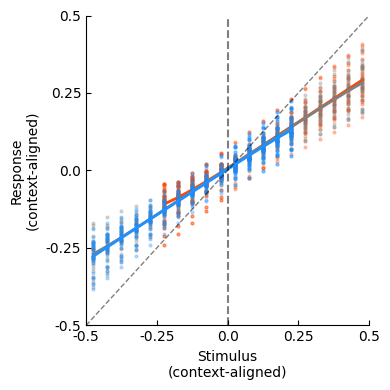

In [17]:
eval_df['stim_aligned'] = eval_df['stim'] - eval_df['boundary']
eval_df['resp_aligned'] = eval_df['y_pred'] - eval_df['boundary']

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.set(xlabel='Stimulus\n(context-aligned)', ylabel='Response\n(context-aligned)',
       xlim=(-0.5, 0.5), ylim=(-0.5, 0.5),
       xticks=np.linspace(-0.5, 0.5, 5), yticks=np.linspace(-0.5, 0.5, 5),
       xticklabels=np.linspace(-0.5, 0.5, 5), yticklabels=np.linspace(-0.5, 0.5, 5))

for cond in conds:
    cond_df = eval_df[eval_df['condition'] == cond]
    ax.plot(cond_df['stim_aligned'], cond_df['resp_aligned'], 'o', markersize=2, alpha=0.1, color=b_colors[cond])
    
    mean_resp = cond_df.groupby('stim_aligned')['resp_aligned'].mean().sort_index()
    ax.plot(mean_resp.index, mean_resp.values, '-', linewidth=2, label=cond, color=b_colors[cond])

ax.axvline(0, color='black', linewidth=1.5, linestyle='--', alpha=0.5)
ax.plot([-0.5, 0.5], [-0.5, 0.5], color = 'black', linewidth=1, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../../figs/ccn/beh-net-stim_vs_resp_aligned.svg', format='svg')
plt.show()


### test for context-shifts

In [18]:
from itertools import combinations
import numpy as np

# Bins over the overlapping stim_aligned range across all contexts
bin_edges = np.linspace(-0.75, 0.75, 21)  # 20 bins of width 0.075

all_within_MSEs = []   # per net
all_between_MSEs = []  # per net

for net_idx in eval_df['net_idx'].unique():
    net_df = eval_df[eval_df['net_idx'] == net_idx]

    # Within-context MSEs (stim_aligned vs resp_aligned for each context)
    net_within_MSEs = []
    for cond in conds:
        context_df = net_df[net_df['condition'] == cond]
        mse = np.mean((context_df['stim_aligned'].values - context_df['resp_aligned'].values) ** 2)
        net_within_MSEs.append(mse)
    all_within_MSEs.append(np.mean(net_within_MSEs))

    # Between-context MSEs: match on stim_aligned bins (NOT unique_stim_idx, which
    # resets per boundary and does not identify the same stimulus across conditions)
    net_between_MSEs = []
    for cond1, cond2 in combinations(conds, 2):
        c1_df = net_df[net_df['condition'] == cond1]
        c2_df = net_df[net_df['condition'] == cond2]

        c1_bins = pd.cut(c1_df['stim_aligned'], bins=bin_edges, labels=False)
        c2_bins = pd.cut(c2_df['stim_aligned'], bins=bin_edges, labels=False)

        c1_mean = c1_df.groupby(c1_bins)['resp_aligned'].mean()
        c2_mean = c2_df.groupby(c2_bins)['resp_aligned'].mean()

        common_bins = c1_mean.index.intersection(c2_mean.index)
        if len(common_bins) == 0:
            mse = np.nan
        else:
            mse = np.mean((c1_mean.loc[common_bins].values - c2_mean.loc[common_bins].values) ** 2)
        net_between_MSEs.append(mse)
    all_between_MSEs.append(np.nanmean(net_between_MSEs))

all_within_MSEs = np.array(all_within_MSEs)
all_between_MSEs = np.array(all_between_MSEs)


Paired t-test: t = -12.028124962226212 p = 8.559605347523044e-13


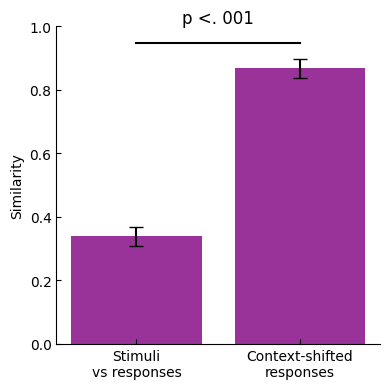

In [19]:
from scipy.stats import ttest_rel

# --- Bar plot: Within vs Between context alignment MSEs ---
fig, axs = plt.subplots(1, 1, figsize=(4, 4))
axs = [axs]  # flatten for consistent indexing
ax = 0

alpha = 100  # adjust as needed for your scale
test_means = all_within_MSEs
test_sds = all_between_MSEs

test_means = np.exp(-alpha * all_within_MSEs)
test_sds = np.exp(-alpha * all_between_MSEs)

means = [test_means.mean(), test_sds.mean()]
sems = [test_means.std() / np.sqrt(len(test_means)),
        test_sds.std() / np.sqrt(len(test_sds))]

bars = axs[ax].bar([0, 1], means, yerr=sems, capsize=5, color=['purple', 'purple'], alpha=0.8)
axs[ax].set(xticks=[0, 1], xticklabels=['Stimuli\nvs responses', 'Context-shifted\nresponses'], ylabel='Similarity')
axs[ax].grid(False)  # Remove grid
# axs[ax].set_title('Responses are Shifted by Contexts')

# Draw only horizontal line connecting bar tops
bar_tops = [means[0] + sems[0], means[1] + sems[1]]
line_y = max(bar_tops) + 0.05
axs[ax].plot([0, 1], [line_y, line_y], color='black', linewidth=1.5)

# Place stars just above the line, within plot area
t_stat, p_val = ttest_rel(test_means, test_sds)
print("Paired t-test: t =", t_stat, "p =", p_val)
axs[ax].text(0.5, line_y + 0.05, 'p <. 001', ha='center', va='bottom', fontsize=12)

# Increase ylim if needed to fit stars
axs[ax].set_ylim(0, line_y + 0.005)
axs[ax].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../../figs/ccn/beh-net-context_similarity.svg', format='svg')
plt.show()

### 6. Check & save

In [20]:
# Stack hidden layer activations from all 30 networks
# Shape: (n_nets, n_trials, n_hidden_units) = (30, 60, 10)
hidden_stack = np.stack([nr['eval_hidden_arr'] for nr in all_nets_detailed_res], axis=0)
print(f'hidden_stack shape: {hidden_stack.shape}')
print(f'hidden_stack contains any NaN: {np.isnan(hidden_stack).any()}')
print(f'hidden_stack contains any inf: {np.isinf(hidden_stack).any()}')


hidden_stack shape: (30, 180, 10)
hidden_stack contains any NaN: False
hidden_stack contains any inf: False


In [21]:
# Verify saved data
print("eval_df columns:", eval_df.columns.tolist())
print("eval_df shape:", eval_df.shape)
print("\nChecking for aligned columns:")
print("  'stim_aligned' in eval_df:", 'stim_aligned' in eval_df.columns)
print("  'resp_aligned' in eval_df:", 'resp_aligned' in eval_df.columns)
if 'stim_aligned' in eval_df.columns:
    print("  stim_aligned sample:", eval_df['stim_aligned'].head().tolist())
if 'resp_aligned' in eval_df.columns:
    print("  resp_aligned sample:", eval_df['resp_aligned'].head().tolist())

eval_df columns: ['condition', 'stim', 'boundary', 'cond_unique_stim_idx', 'class', 'y_pred', 'class_pred', 'net_idx', 'stim_aligned', 'resp_aligned']
eval_df shape: (5400, 10)

Checking for aligned columns:
  'stim_aligned' in eval_df: True
  'resp_aligned' in eval_df: True
  stim_aligned sample: [-0.475, -0.425, -0.375, -0.32499999999999996, -0.275]
  resp_aligned sample: [-0.2921452075242996, -0.25966909527778625, -0.2284640073776245, -0.19732558727264404, -0.1661871075630188]


In [22]:
beh_df.to_csv('../../data/simulations/beh_df.csv', index=False)
np.save('../../data/simulations/hidden_stack.npy', hidden_stack)   # shape (30, 60, 10)
print("Saved: beh_df.csv, hidden_stack.npy")

NameError: name 'beh_df' is not defined

### TESTING RDMs (MOVE TO NEXT NOTEBOOK)

In [ ]:
beh_df      = pd.read_csv('../../data/simulations/beh_df.csv')
beh_df.head()

,condition,stim,boundary,cond_unique_stim_idx,class,y_pred,class_pred,net_idx,stim_aligned,resp_aligned
0,base,0.025,0.5,0,0,0.207855,-0.699431,0,-0.475,-0.292145
1,base,0.075,0.5,1,0,0.240331,-0.634813,0,-0.425,-0.259669
2,base,0.125,0.5,2,0,0.271536,-0.553386,0,-0.375,-0.228464
3,base,0.175,0.5,3,0,0.302674,-0.471079,0,-0.325,-0.197326
4,base,0.225,0.5,4,0,0.333813,-0.388771,0,-0.275,-0.166187


In [ ]:
hidden_stack = np.load('../../data/simulations/hidden_stack.npy')
print(f'hidden_stack shape: {hidden_stack.shape}')  # (n_nets, n_trials, n_units)
hidden_mean = hidden_stack.mean(axis=0)
print(f'hidden_mean shape: {hidden_mean.shape}')

# Get boundaries from beh_df instead
boundaries = tuple(sorted(beh_df['boundary'].unique()))
print(f'boundaries: {boundaries}')

hidden_stack shape: (30, 180, 10)
hidden_mean shape: (180, 10)
boundaries: (np.float64(0.25), np.float64(0.5), np.float64(0.7500000000000001))


### 2. Population: PCA

In [ ]:
sns.set(context='paper')
sns.set_style('white')
from matplotlib.lines import Line2D

conds = ['curv', 'base', 'flat']
cond2bound = {'curv': 0.25, 'base': 0.50, 'flat': 0.75}
cond2colors = {'curv': 'orangered', 'base': 'gray', 'flat': 'dodgerblue'}

# average hidden activations across networks for each of the test trials
hidden_mean = hidden_stack.mean(axis=0)

# Create pca_df from test trial metadata (one row per trial, averaged across networks)
pca_df = beh_df[beh_df['net_idx'] == 0][['boundary', 'condition', 'stim', 'class', 'unique_stim_idx', 'rep']].reset_index(drop=True)

# raw PCA
pca = PCA(n_components=3)
pcs = pca.fit_transform(hidden_mean)
pca_df['PC1'] = pcs[:, 0]
pca_df['PC2'] = pcs[:, 1]
pca_df['PC3'] = pcs[:, 2]
pca_df['stim_aligned'] = beh_df.loc[pca_df.index, 'stim_aligned'].values

# Print explained variance ratio for each PC
explained_var = pca.explained_variance_ratio_
print('Explained variance by PC (original space):')
for i, var in enumerate(explained_var, 1):
    print(f'  PC{i}: {var*100:.2f}%')

# shared norm over global stim range
shared_norm = Normalize(vmin=pca_df['stim'].min(), vmax=pca_df['stim'].max())

# marker per condition
cond_markers = {'curv': 's', 'base': 'o', 'flat': '^'}

# hidden-centroid-subtracted, then PCA
hidden_centered = hidden_mean.copy()
for cond in conds:
    idx = pca_df[pca_df['condition'] == cond].index
    hidden_centered[idx] = hidden_mean[idx] - hidden_mean[idx].mean(axis=0)
pca2 = PCA(n_components=2)
pcs2 = pca2.fit_transform(hidden_centered)
pca_df['PC1_aligned'] = pcs2[:, 0]
pca_df['PC2_aligned'] = pcs2[:, 1]
# pca_df['PC3_aligned'] = pcs2[:, 2]

# Print explained variance ratio for each PC
explained_var = pca2.explained_variance_ratio_
print('Explained variance by PC (aligned space):')
for i, var in enumerate(explained_var, 1):
    print(f'  PC{i}: {var*100:.2f}%')

print('PCA setup done.')


KeyError: "['unique_stim_idx', 'rep'] not in index"

In [ ]:
# Multivariate RDMs: each cell is the Euclidean distance between two stimulus-level neuron vectors.
# First average over networks, then average repeats within each stimulus inside each condition.

fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharex=False, sharey=False)

for ax_idx, cond in enumerate(conds):
    cond_rows = pca_df[pca_df['condition'] == cond].sort_values('unique_stim_idx')
    stim_ids = cond_rows['unique_stim_idx'].unique()
    vectors = np.array([
        hidden_mean[cond_rows[cond_rows['unique_stim_idx'] == stim_id].index].mean(axis=0)
        for stim_id in stim_ids
    ])
    rdm = np.sqrt(((vectors[:, None, :] - vectors[None, :, :]) ** 2).sum(axis=2))

    sns.heatmap(rdm, ax=axes[ax_idx], cmap='viridis', square=True, vmin=0, vmax=rdm.max(), cbar=True)
    axes[ax_idx].set(title=f'{cond} context',
                     xlabel='Stimulus\n(shape position)',
                     ylabel='Stimulus\n(shape position)' if ax_idx == 0 else '')

plt.tight_layout()
plt.show()
